In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Use raw string to handle Windows file paths
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize and pad text data
max_words = 5000  # Maximum number of words in the vocabulary
max_len = 100     # Maximum sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data[text_column])
X = tokenizer.texts_to_sequences(data[text_column])
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

y = data[target_column]

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Build the GRU model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    GRU(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 4: Train the GRU model
print("Training GRU Model...")
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

# Step 5: Evaluate the GRU model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"GRU Test Accuracy: {accuracy * 100:.2f}%")

# Step 6: Save the trained GRU model
model_path = r"C:\Users\PC\Downloads\GRU_model.h5"  # File path to save the model
model.save(model_path)
print(f"Trained GRU model saved to {model_path}")

# Step 7: Make predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Step 8: Compute Precision, Recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Step 9: Display Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Training GRU Model...
Epoch 1/5
4641/4641 [==============================] - 221s 47ms/step - loss: 0.1936 - accuracy: 0.9238 - val_loss: 0.1355 - val_accuracy: 0.9466
Epoch 2/5
4641/4641 [==============================] - 212s 46ms/step - loss: 0.1209 - accuracy: 0.9547 - val_loss: 0.1313 - val_accuracy: 0.9490
Epoch 3/5
4641/4641 [==============================] - 223s 48ms/step - loss: 0.1034 - accuracy: 0.9612 - val_loss: 0.1362 - val_accuracy: 0.9466
Epoch 4/5
4641/4641 [==============================] - 218s 47ms/step - loss: 0.0864 - accuracy: 0.9673 - val_loss: 0.1408 - val_accuracy: 0.9470
Epoch 5/5
1451/1451 [==============================] - 14s 10ms/step - loss: 0.1577 - accuracy: 0.9490
GRU Test Accuracy: 94.90%


C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Trained GRU model saved to C:\Users\PC\Downloads\GRU_model.h5
1451/1451 [==============================] - 19s 9ms/step
Precision: 0.9501
Recall: 0.9475
F1 Score: 0.9488
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     23238
           1       0.95      0.95      0.95     23171

    accuracy                           0.95     46409
   macro avg       0.95      0.95      0.95     46409
weighted avg       0.95      0.95      0.95     46409



1451/1451 [==============================] - 14s 9ms/step


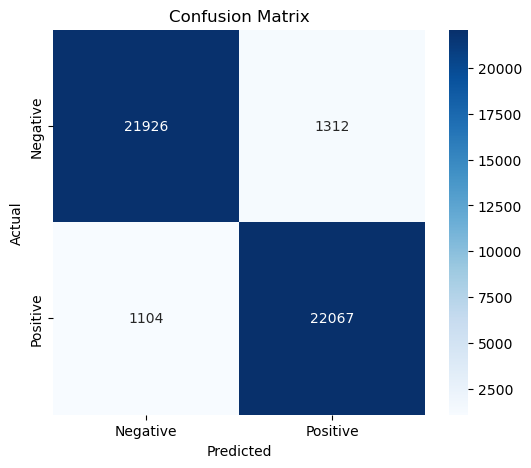

Confusion Matrix:
[[21926  1312]
 [ 1104 22067]]


In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Print confusion matrix values
print("Confusion Matrix:")
print(cm)


1451/1451 [==============================] - 13s 8ms/step


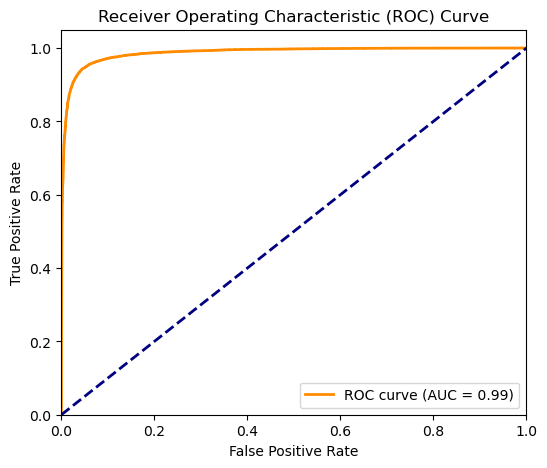

In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = model.predict(X_test)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line (no skill)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


1451/1451 [==============================] - 12s 8ms/step
GRU MAE: 0.0521, MSE: 0.0521, RMSE: 0.2282


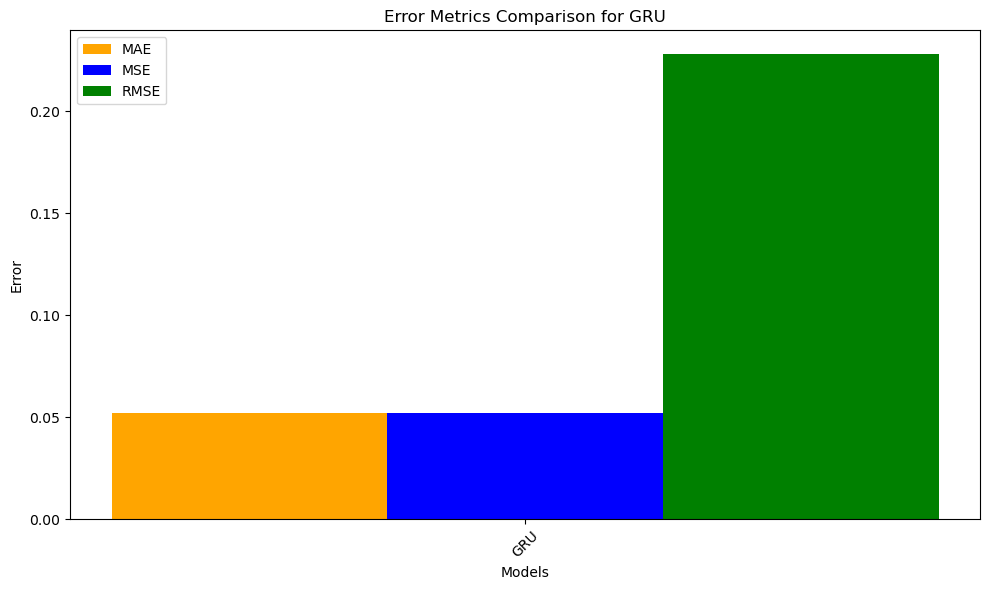

In [7]:
# Predict on the test set using the existing GRU model
y_pred_gru_prob = model.predict(X_test)  # Get predicted probabilities
from tensorflow.keras.models import load_model

# Load the pre-trained GRU model from a saved file
model_path = r"C:\Users\PC\Downloads\GRU_model.h5"  # Replace with your model's file path
gru_model = load_model(model_path)

# Predict on the test set
y_pred_gru_prob = gru_model.predict(X_test)  # Get predicted probabilities
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Use the existing GRU model or load it
# Uncomment the next line if you need to load a saved model
# gru_model = load_model(model_path)

# Predict on the test set
y_pred_gru_prob = model.predict(X_test)  # Replace 'model' with 'gru_model' if loading a saved model

# Convert probabilities to binary predictions
y_pred_gru = (y_pred_gru_prob > 0.5).astype("int32")

# Calculate error metrics
mae_gru = mean_absolute_error(y_test, y_pred_gru)
mse_gru = mean_squared_error(y_test, y_pred_gru)
rmse_gru = np.sqrt(mse_gru)

# Store error metrics
error_metrics = {}
error_metrics["GRU"] = {"MAE": mae_gru, "MSE": mse_gru, "RMSE": rmse_gru}

# Print metrics
print(f"GRU MAE: {mae_gru:.4f}, MSE: {mse_gru:.4f}, RMSE: {rmse_gru:.4f}")

# Plot the error metrics
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison for GRU')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


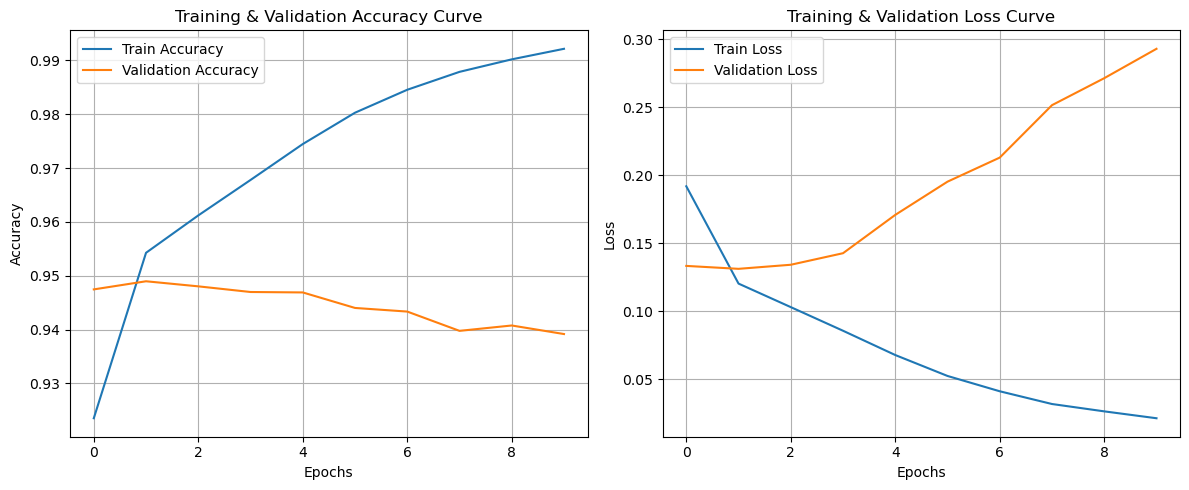

In [6]:
import matplotlib.pyplot as plt

# Plot Accuracy Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy Curve')
plt.legend()
plt.grid()

# Plot Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Curve')
plt.legend()
plt.grid()

# Show the plots
plt.tight_layout()
plt.show()
